In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the key tables
races = pd.read_csv('../data/races.csv')
results = pd.read_csv('../data/results.csv')
# 'grid' uses the Ergast MySQL-dump '\N' NULL placeholder for a handful of
# rows (2025 entries with no formal grid slot recorded yet); pandas can't
# infer a numeric dtype for a column containing that literal string, so it
# loads as text and breaks every numeric comparison/arithmetic on 'grid'
# used throughout this notebook. Coerce to numeric here, at the source,
# same 0 = no-formal-grid-position convention already used elsewhere.
results['grid'] = pd.to_numeric(results['grid'], errors='coerce').fillna(0).astype(int)
drivers = pd.read_csv('../data/drivers.csv')
constructors = pd.read_csv('../data/constructors.csv')
qualifying = pd.read_csv('../data/qualifying.csv')
driver_standings = pd.read_csv('../data/driver_standings.csv')
constructor_standings = pd.read_csv('../data/constructor_standings.csv')
# Same '\N' NULL-placeholder issue as 'grid' above, in a handful of
# standings rows - coerce to numeric so championship-position features work.
driver_standings['position'] = pd.to_numeric(driver_standings['position'], errors='coerce')
constructor_standings['position'] = pd.to_numeric(constructor_standings['position'], errors='coerce')

status = pd.read_csv('../data/status.csv')

circuits = pd.read_csv('../data/circuits.csv', encoding='latin-1')

print("✅ All files loaded!")
print(f"Races: {races.shape}")
print(f"Results: {results.shape}")
print(f"Drivers: {drivers.shape}")
print(f"Qualifying: {qualifying.shape}")
print(f"Driver standings: {driver_standings.shape}")

✅ All files loaded!
Races: (1171, 18)
Results: (27414, 18)
Drivers: (865, 9)
Qualifying: (11146, 9)
Driver standings: (35537, 7)


In [2]:
# Filter to modern era (2010 onwards) and explore the results table
races_modern = races[races['year'] >= 2010].copy()
print(f"Modern era races (2010+): {len(races_modern)}")
print(f"Years covered: {races_modern['year'].min()} - {races_modern['year'].max()}")
print(f"\nRaces per year:")
print(races_modern.groupby('year')['raceId'].count().to_string())

Modern era races (2010+): 351
Years covered: 2010 - 2026

Races per year:
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    24
2026    22


In [3]:
# Look at the results table - this is the most important table
print("Results table columns:")
print(results.columns.tolist())
print("\nFirst 3 rows:")
print(results.head(3).to_string())
print("\nUnique finish positions:")
print(sorted(results['positionOrder'].unique()))

Results table columns:
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

First 3 rows:
   resultId  raceId  driverId  constructorId number  grid position positionText  positionOrder  points  laps         time milliseconds fastestLap rank fastestLapTime fastestLapSpeed  statusId
0         1      18         1              1     22     1        1            1              1    10.0    58  1:34:50.616      5690616         39    2       1:27.452         218.300         1
1         2      18         2              2      3     5        2            2              2     8.0    58       +5.478      5696094         41    3       1:27.739         217.586         1
2         3      18         3              3      7     7        3            3              3     6.0    58       +8.163      5698779         41    5       1

In [4]:
# Merge everything into one master dataframe
# Start with results + races to get the year
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId')

# Add driver names
df = df.merge(drivers[['driverId', 'driverRef', 'forename', 'surname', 'nationality']], on='driverId')

# Add constructor names
df = df.merge(constructors[['constructorId', 'constructorRef', 'name']], on='constructorId', suffixes=('_race', '_constructor'))

# Add circuit info
df = df.merge(circuits[['circuitId', 'circuitRef', 'country']], on='circuitId')

# Add finish status (DNF, Finished, etc.)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Filter to modern era
df = df[df['year'] >= 2010].copy()


# Create our target variable - podium finish (top 3)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# Create full driver name for readability
df['driver_name'] = df['forename'] + ' ' + df['surname']

print(f"Master dataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nPodium finishes in dataset: {df['podium'].sum()}")
print(f"Non-podium: {(df['podium'] == 0).sum()}")
print(f"\nSample row:")
print(df[['year', 'round', 'driver_name', 'name_constructor', 'grid', 'positionOrder', 'podium', 'status']].head(5).to_string())

Master dataframe shape: (7058, 33)

Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name_race', 'driverRef', 'forename', 'surname', 'nationality', 'constructorRef', 'name_constructor', 'circuitRef', 'country', 'status', 'podium', 'driver_name']

Podium finishes in dataset: 1011
Non-podium: 6047

Sample row:
       year  round       driver_name name_constructor  grid  positionOrder  podium    status
20320  2010      1   Fernando Alonso          Ferrari     3              1       1  Finished
20321  2010      1      Felipe Massa          Ferrari     2              2       1  Finished
20322  2010      1    Lewis Hamilton          McLaren     4              3       1  Finished
20323  2010      1  Sebastian Vettel         Red Bull     1              4       0  Finished
20324 

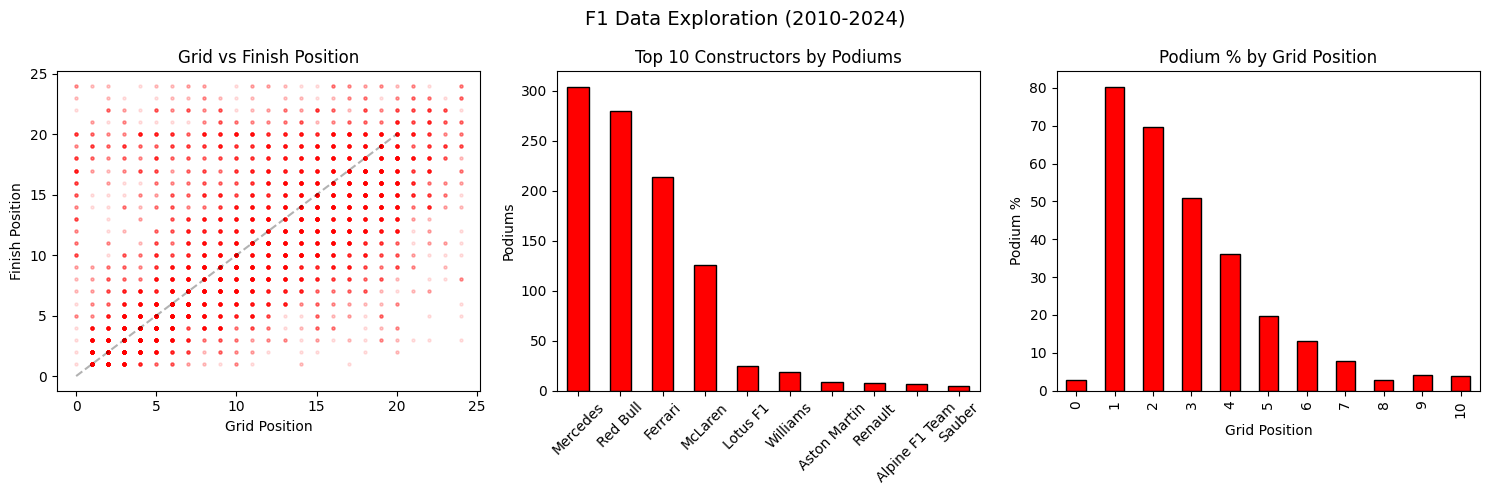

Charts saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('F1 Data Exploration (2010-2024)', fontsize=14)

# Plot 1: Grid position vs finish position
axes[0].scatter(df['grid'], df['positionOrder'], alpha=0.1, color='red', s=5)
axes[0].set_xlabel('Grid Position')
axes[0].set_ylabel('Finish Position')
axes[0].set_title('Grid vs Finish Position')
axes[0].plot([0, 20], [0, 20], 'k--', alpha=0.3)  # diagonal reference line

# Plot 2: Top 10 constructors by podiums
podiums_by_team = df[df['podium']==1].groupby('name_constructor')['podium'].count()
podiums_by_team.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], color='red', edgecolor='black'
)
axes[1].set_title('Top 10 Constructors by Podiums')
axes[1].set_xlabel('')
axes[1].set_ylabel('Podiums')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Podium rate from each grid position (1-10)
grid_podium = df[df['grid'] <= 10].groupby('grid')['podium'].mean() * 100
grid_podium.plot(kind='bar', ax=axes[2], color='red', edgecolor='black')
axes[2].set_title('Podium % by Grid Position')
axes[2].set_xlabel('Grid Position')
axes[2].set_ylabel('Podium %')

plt.tight_layout()
plt.savefig('../data/exploration_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

In [6]:
# Sort everything chronologically - critical for time-based features
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

# ── Feature 1: Driver's podium rate at this specific circuit ──
circuit_history = (
    df.groupby(['driverId', 'circuitId'])['podium']
    .mean()
    .reset_index()
    .rename(columns={'podium': 'driver_circuit_podium_rate'})
)
df = df.merge(circuit_history, on=['driverId', 'circuitId'], how='left')

# ── Feature 2: Driver recent form (avg finish position, last 3 races) ──
df['driver_recent_form'] = (
    df.groupby('driverId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Feature 3: Constructor recent form (avg finish, last 3 races) ──
df['constructor_recent_form'] = (
    df.groupby('constructorId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Feature 4: Driver DNF rate (reliability signal) ──
df['is_dnf'] = (df['positionOrder'] > df['laps'].map(
    df.groupby('raceId')['laps'].max()
) + 1).astype(int)

df['driver_dnf_rate'] = (
    df.groupby('driverId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# ── Feature 5: Constructor DNF rate ──
df['constructor_dnf_rate'] = (
    df.groupby('constructorId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

print("Features created!")
print(df[['driver_name', 'year', 'round', 'grid', 'podium',
          'driver_circuit_podium_rate', 'driver_recent_form',
          'constructor_recent_form', 'driver_dnf_rate']].head(10).to_string())

Features created!
          driver_name  year  round  grid  podium  driver_circuit_podium_rate  driver_recent_form  constructor_recent_form  driver_dnf_rate
0     Fernando Alonso  2010      1     3       1                    0.166667                 NaN                      NaN              NaN
1        Felipe Massa  2010      1     2       1                    0.142857                 NaN                      1.0              NaN
2      Lewis Hamilton  2010      1     4       1                    0.666667                 NaN                      NaN              NaN
3    Sebastian Vettel  2010      1     1       0                    0.333333                 NaN                      NaN              NaN
4        Nico Rosberg  2010      1     5       0                    0.500000                 NaN                      NaN              NaN
5  Michael Schumacher  2010      1     7       0                    0.000000                 NaN                      5.0              NaN
6       J

In [7]:
# Fix sort - needs to go oldest to newest for rolling features to work correctly
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

# Merge in championship standings BEFORE each race
# (standings reflect points entering that race, not after)
driver_standings_clean = driver_standings.rename(columns={
    'points': 'driver_champ_points',
    'position': 'driver_champ_position'
})

constructor_standings_clean = constructor_standings.rename(columns={
    'points': 'constructor_champ_points', 
    'position': 'constructor_champ_position'
})

df = df.merge(
    driver_standings_clean[['raceId', 'driverId', 'driver_champ_points', 'driver_champ_position']],
    on=['raceId', 'driverId'],
    how='left'
)

df = df.merge(
    constructor_standings_clean[['raceId', 'constructorId', 'constructor_champ_points', 'constructor_champ_position']],
    on=['raceId', 'constructorId'],
    how='left'
)

# Fill NaN standings with 0 (start of season = 0 points)
df['driver_champ_points'] = df['driver_champ_points'].fillna(0)
df['constructor_champ_points'] = df['constructor_champ_points'].fillna(0)
df['driver_recent_form'] = df['driver_recent_form'].fillna(10)
df['constructor_recent_form'] = df['constructor_recent_form'].fillna(10)
df['driver_dnf_rate'] = df['driver_dnf_rate'].fillna(0)
df['constructor_dnf_rate'] = df['constructor_dnf_rate'].fillna(0)
df['driver_circuit_podium_rate'] = df['driver_circuit_podium_rate'].fillna(0)

# Final feature set
FEATURES = [
    'grid',
    'driver_champ_points',
    'constructor_champ_points', 
    'driver_circuit_podium_rate',
    'driver_recent_form',
    'constructor_recent_form',
    'driver_dnf_rate',
    'constructor_dnf_rate'
]

TARGET = 'podium'

# Check no nulls remain in our features
print("Null counts in features:")
print(df[FEATURES + [TARGET]].isnull().sum())
print(f"\nDataset ready: {df.shape[0]} rows, {len(FEATURES)} features")
print(f"\nSample with all features:")
print(df[['driver_name', 'year', 'round'] + FEATURES + [TARGET]].head(8).to_string())

Null counts in features:
grid                          0
driver_champ_points           0
constructor_champ_points      0
driver_circuit_podium_rate    0
driver_recent_form            0
constructor_recent_form       0
driver_dnf_rate               0
constructor_dnf_rate          0
podium                        0
dtype: int64

Dataset ready: 7058 rows, 8 features

Sample with all features:
          driver_name  year  round  grid  driver_champ_points  constructor_champ_points  driver_circuit_podium_rate  driver_recent_form  constructor_recent_form  driver_dnf_rate  constructor_dnf_rate  podium
0     Fernando Alonso  2010      1     3                 25.0                      43.0                    0.166667                10.0                     10.0              0.0                   0.0       1
1        Felipe Massa  2010      1     2                 18.0                      43.0                    0.142857                10.0                      1.0              0.0                

In [8]:
# Sanity check - how many races and years do we have?
print("Rows per year:")
print(df.groupby('year')['raceId'].nunique().to_string())
print(f"\nTotal unique races: {df['raceId'].nunique()}")
print(f"Total rows: {len(df)}")


Rows per year:
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    24
2026     8

Total unique races: 337
Total rows: 7058


In [9]:
# Start fresh from the clean merged df
# Reload to make sure we're working from the full dataset
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId')
df = df.merge(drivers[['driverId', 'driverRef', 'forename', 'surname']], on='driverId')
df = df.merge(constructors[['constructorId', 'constructorRef', 'name']], on='constructorId', suffixes=('_race', '_constructor'))
df = df.merge(circuits[['circuitId', 'circuitRef']], on='circuitId')
df = df.merge(status[['statusId', 'status']], on='statusId')

df = df[df['year'] >= 2010].copy()
df['podium'] = (df['positionOrder'] <= 3).astype(int)
df['driver_name'] = df['forename'] + ' ' + df['surname']
df['is_dnf'] = (~df['status'].isin(['Finished', '+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps'])).astype(int)

# Sort oldest to newest
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

print(f"Full dataset restored: {df.shape}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")

Full dataset restored: (7058, 32)
Years: 2010 - 2026


In [10]:
# Calculate cumulative points BEFORE each race (shift by 1 race)
# This is what the model would actually know before race day

# ── LEAK-FIX helper for constructor-level features ──
# A constructor has TWO rows per race (both cars), so computing a feature via
# groupby('constructorId').shift(1) on this per-driver frame lets the second
# car read its TEAMMATE'S same-race result as "entering the race" (a same-race
# leak on ~50% of rows). Fix: reduce to ONE value per (raceId, constructorId),
# shift/roll across races chronologically, then broadcast back to both cars.
def constructor_feature(df, value_col, race_agg, transform, fill, season_scoped):
    race = (df.groupby(['constructorId', 'raceId', 'year', 'round'])[value_col]
              .agg(race_agg).reset_index(name='_v')
              .sort_values(['year', 'round']).reset_index(drop=True))
    keys = ['year', 'constructorId'] if season_scoped else ['constructorId']
    race['_out'] = race.groupby(keys)['_v'].transform(transform).fillna(fill)
    return df.merge(race[['raceId', 'constructorId', '_out']],
                    on=['raceId', 'constructorId'], how='left')['_out'].values

# Drivers cumulative points entering each race
df['driver_season_points'] = (
    df.groupby(['year', 'driverId'])['points']
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

# Constructor cumulative points entering each race — LEAK-FIXED: per race =
# SUM of both cars' points (constructor championship scoring), season cumsum.
df['constructor_season_points'] = constructor_feature(
    df, 'points', 'sum', lambda x: x.shift(1).cumsum().fillna(0), 0, season_scoped=True)

# Drivers recent form - avg finish last 3 races
df['driver_recent_form'] = (
    df.groupby('driverId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
).fillna(10)

# Constructor recent form — LEAK-FIXED: per race = MEAN of both cars'
# finishing positions, then mean over the team's previous 3 races.
df['constructor_recent_form'] = constructor_feature(
    df, 'positionOrder', 'mean', lambda x: x.shift(1).rolling(3, min_periods=1).mean(), 10, season_scoped=False)

# Driver DNF rate (last 10 races)
df['driver_dnf_rate'] = (
    df.groupby('driverId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
).fillna(0)

# Constructor DNF rate — LEAK-FIXED: per race = MEAN of both cars' is_dnf
# (per-car DNF fraction 0/0.5/1), then mean over the team's previous 10 races.
df['constructor_dnf_rate'] = constructor_feature(
    df, 'is_dnf', 'mean', lambda x: x.shift(1).rolling(10, min_periods=1).mean(), 0, season_scoped=False)

# Driver podium rate at this circuit — exponentially decayed by year (decay=0.75)
# Uses only strictly past years to avoid data leakage.
_yr_cir = (
    df.groupby(['driverId', 'circuitId', 'year'])['podium']
    .mean().reset_index()
    .rename(columns={'podium': '_yr_rate'})
)
_cross = (
    df[['driverId', 'circuitId', 'year']].drop_duplicates()
    .rename(columns={'year': 'race_year'})
)
_cross = _cross.merge(_yr_cir, on=['driverId', 'circuitId'])
_cross = _cross[_cross['year'] < _cross['race_year']]          # past years only
_cross['_w']  = 0.75 ** (_cross['race_year'] - _cross['year'])
_cross['_wp'] = _cross['_yr_rate'] * _cross['_w']
_agg = (
    _cross.groupby(['driverId', 'circuitId', 'race_year'])
    .agg(_wsum=('_wp', 'sum'), _wtot=('_w', 'sum'))
    .reset_index()
)
_agg['driver_circuit_podium_rate'] = (_agg['_wsum'] / _agg['_wtot']).fillna(0)
_agg = _agg.rename(columns={'race_year': 'year'})
df = df.merge(
    _agg[['driverId', 'circuitId', 'year', 'driver_circuit_podium_rate']],
    on=['driverId', 'circuitId', 'year'], how='left'
)
df['driver_circuit_podium_rate'] = df['driver_circuit_podium_rate'].fillna(0)

# Points scored across driver's last 5 races (cross-season rolling sum)
df['driver_last5_points'] = (
    df.groupby('driverRef')['points']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum())
).fillna(0)

FEATURES = [
    'grid',
    'driver_season_points',
    'constructor_season_points',
    'driver_circuit_podium_rate',
    'driver_recent_form',
    'constructor_recent_form',
    'driver_dnf_rate',
    'constructor_dnf_rate',
    'driver_last5_points',
]

TARGET = 'podium'

print("Null check:")
print(df[FEATURES + [TARGET]].isnull().sum())
print(f"\nDataset: {df.shape[0]} rows across {df['year'].nunique()} years")
print(f"\nRows per year:")
print(df.groupby('year')['raceId'].nunique().to_string())

Null check:
grid                          0
driver_season_points          0
constructor_season_points     0
driver_circuit_podium_rate    0
driver_recent_form            0
constructor_recent_form       0
driver_dnf_rate               0
constructor_dnf_rate          0
driver_last5_points           0
podium                        0
dtype: int64

Dataset: 7058 rows across 17 years

Rows per year:
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    24
2026     8


## Weather Features — Evaluated, Not Adopted

Tested `wet_race` + `driver_wet_delta` (see feature engineering and retrain-comparison cells below). Result: **rejected**.

| Model | Metric | Before | After |
|---|---|---|---|
| Podium | ROC-AUC | 0.942 | 0.931 |
| Winner | ROC-AUC | 0.973 | 0.959 |
| Qualifying | RMSE / MAE / Top-10 | 3.87 / 3.04 / 77.8% | unchanged |

**Root cause:** only 57 wet races in the training data (2010-2024) — insufficient signal density for the classifiers to learn a real wet-weather pattern without overfitting. The feature-engineering cells and the retrain/comparison cells are kept below for documentation, but the retrain cells are commented out so re-running this notebook top-to-bottom always reproduces the baseline production models (the ones actually saved to `backend/*.pkl`).

## Weather Features (Open-Meteo)

Adds two experimental features from `data/race_weather.csv` (fetched via `data/fetch_weather.py`, Open-Meteo's free historical archive API — no key required):

- `wet_race` — binary, 1 if more than 1.0mm of rain fell in the 12:00–17:00 local race window
- `driver_wet_delta` — each driver's average position gain (`grid - positionOrder`) in past **wet** races minus past **dry** races, using only races from strictly earlier years (`year < race_year`) to avoid leakage. Positive = driver historically gains more positions in the wet. Filled with 0 when a driver has no wet (or no dry) race history yet.

In [11]:
# ── wet_race: merge in the race-day precipitation classification ──
race_weather = pd.read_csv('../data/race_weather.csv')
df = df.merge(race_weather[['raceId', 'wet_race']], on='raceId', how='left')

missing_weather = df['wet_race'].isnull().sum()
df['wet_race'] = df['wet_race'].fillna(0).astype(int)

print(f"Rows missing weather data (defaulted to dry): {missing_weather} of {len(df)}")
races_wet = df.groupby('raceId')['wet_race'].first()
print(f"Wet races: {races_wet.sum()} of {len(races_wet)} ({races_wet.mean():.1%})")

Rows missing weather data (defaulted to dry): 0 of 7058
Wet races: 57 of 337 (16.9%)


In [12]:
# ── driver_wet_delta: driver's historical (grid - positionOrder) edge in wet
# vs dry races, using only races from strictly earlier years (no leakage). ──
df['position_gain'] = df['grid'] - df['positionOrder']

_pairs = df[['driverId', 'year']].drop_duplicates().rename(columns={'year': 'race_year'})
_hist = df[['driverId', 'year', 'wet_race', 'position_gain']]

_past = _pairs.merge(_hist, on='driverId')
_past = _past[_past['year'] < _past['race_year']]   # past years only

_wet_avg = (
    _past[_past['wet_race'] == 1]
    .groupby(['driverId', 'race_year'])['position_gain'].mean()
    .rename('driver_wet_avg_gain').reset_index()
    .rename(columns={'race_year': 'year'})
)
_dry_avg = (
    _past[_past['wet_race'] == 0]
    .groupby(['driverId', 'race_year'])['position_gain'].mean()
    .rename('driver_dry_avg_gain').reset_index()
    .rename(columns={'race_year': 'year'})
)

df = df.merge(_wet_avg, on=['driverId', 'year'], how='left')
df = df.merge(_dry_avg, on=['driverId', 'year'], how='left')

df['driver_wet_delta'] = (df['driver_wet_avg_gain'] - df['driver_dry_avg_gain']).fillna(0)
df = df.drop(columns=['driver_wet_avg_gain', 'driver_dry_avg_gain'])

print("Null check:", df['driver_wet_delta'].isnull().sum())
print(df['driver_wet_delta'].describe())
print("\nSample (non-zero driver_wet_delta):")
print(df.loc[df['driver_wet_delta'] != 0, ['driver_name', 'year', 'round', 'wet_race', 'driver_wet_delta']].head(10).to_string())

Null check: 0
count    7058.000000
mean       -0.169735
std         2.074850
min       -10.571429
25%        -1.333333
50%         0.000000
75%         0.932893
max         8.250000
Name: driver_wet_delta, dtype: float64

Sample (non-zero driver_wet_delta):
           driver_name  year  round  wet_race  driver_wet_delta
456   Sebastian Vettel  2011      1         0         -5.000000
457     Lewis Hamilton  2011      1         0         -1.250000
458      Vitaly Petrov  2011      1         0          6.933333
459    Fernando Alonso  2011      1         0         -3.633333
460        Mark Webber  2011      1         0         -4.100000
461      Jenson Button  2011      1         0         -6.300000
462       Felipe Massa  2011      1         0          6.150000
463    Sébastien Buemi  2011      1         0         -3.250000
464       Adrian Sutil  2011      1         0          1.366667
466  Jaime Alguersuari  2011      1         0         -2.933333


## Qualifying Position Model — Feature Engineering

Builds `quali_position` (the regression target) plus four supporting features from `qualifying.csv`, reusing the same exponential-decay circuit-history and rolling/expanding patterns already used for the podium/winner features above.

In [13]:
# ── Qualifying Feature Engineering ──
# Merges qualifying.csv onto the master df to build a qualifying-position
# target plus four supporting features, reusing the same decay/rolling
# patterns as the podium features above (driver_circuit_podium_rate etc).

qualifying_clean = qualifying[['raceId', 'driverId', 'position']].rename(
    columns={'position': 'quali_position'}
)
df = df.merge(qualifying_clean, on=['raceId', 'driverId'], how='left')

# qualifying.csv has zero rows for 2025+ in this dataset, so grid position is
# used as the documented fallback (strongly correlated with actual quali
# position). This means quali_position for the entire 2025-2026 test period
# is actually the grid position, not a verified qualifying result.
missing_mask = df['quali_position'].isnull()
df['quali_position'] = df['quali_position'].fillna(df['grid'])

# ── driver_circuit_quali_avg: exponentially-decayed historical quali avg at
# this circuit (same weighting scheme as driver_circuit_podium_rate, decay=0.75) ──
_yr_cir_q = (
    df.groupby(['driverId', 'circuitId', 'year'])['quali_position']
    .mean().reset_index()
    .rename(columns={'quali_position': '_yr_avg'})
)
_cross_q = (
    df[['driverId', 'circuitId', 'year']].drop_duplicates()
    .rename(columns={'year': 'race_year'})
)
_cross_q = _cross_q.merge(_yr_cir_q, on=['driverId', 'circuitId'])
_cross_q = _cross_q[_cross_q['year'] < _cross_q['race_year']]          # past years only
_cross_q['_w']  = 0.75 ** (_cross_q['race_year'] - _cross_q['year'])
_cross_q['_wp'] = _cross_q['_yr_avg'] * _cross_q['_w']
_agg_q = (
    _cross_q.groupby(['driverId', 'circuitId', 'race_year'])
    .agg(_wsum=('_wp', 'sum'), _wtot=('_w', 'sum'))
    .reset_index()
)
_agg_q['driver_circuit_quali_avg'] = _agg_q['_wsum'] / _agg_q['_wtot']
_agg_q = _agg_q.rename(columns={'race_year': 'year'})
df = df.merge(
    _agg_q[['driverId', 'circuitId', 'year', 'driver_circuit_quali_avg']],
    on=['driverId', 'circuitId', 'year'], how='left'
)
df['driver_circuit_quali_avg'] = df['driver_circuit_quali_avg'].fillna(11.0)

# ── driver_season_quali_avg: driver's average quali position so far this season ──
df['driver_season_quali_avg'] = (
    df.groupby(['year', 'driverId'])['quali_position']
    .transform(lambda x: x.shift(1).expanding().mean())
).fillna(11.0)

# ── constructor_season_quali_avg: team's avg quali position so far this season
# — LEAK-FIXED: per race = MEAN of both cars' quali positions, season expanding. ──
df['constructor_season_quali_avg'] = constructor_feature(
    df, 'quali_position', 'mean', lambda x: x.shift(1).expanding().mean(), 11.0, season_scoped=True)

# ── driver_last3_quali_avg: rolling avg quali position over driver's last 3 races (cross-season) ──
df['driver_last3_quali_avg'] = (
    df.groupby('driverId')['quali_position']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
).fillna(11.0)

QUALI_FEATURES = [
    'constructor_season_points',
    'constructor_season_quali_avg',
    'driver_circuit_quali_avg',
    'driver_season_quali_avg',
    'driver_last3_quali_avg',
    'driver_recent_form',
    'driver_last5_points',
    'driver_dnf_rate',
]
QUALI_TARGET = 'quali_position'

# ── driver_championship_position: driver's championship POSITION entering
# this race (i.e. as of their previous race), not raw points - normalized
# 1-22 regardless of points-scoring-system changes across seasons ──
_ds = driver_standings[['raceId', 'driverId', 'position']].rename(
    columns={'position': '_driver_champ_pos_raw'}
)
df = df.merge(_ds, on=['raceId', 'driverId'], how='left')
df['driver_championship_position'] = (
    df.groupby('driverId')['_driver_champ_pos_raw'].transform(lambda x: x.shift(1))
).fillna(11)
df = df.drop(columns=['_driver_champ_pos_raw'])

# ── constructor_championship_position: from constructor_standings — LEAK-FIXED.
# The standings position is one value per (raceId, constructorId) merged onto
# BOTH cars, so dedup to one row per race BEFORE shifting, else the second car
# reads this race's own (post-race) standing. Broadcast the shifted value back. ──
_cs = constructor_standings[['raceId', 'constructorId', 'position']].rename(
    columns={'position': '_ccp'}
)
_ccp_race = (
    df[['constructorId', 'raceId', 'year', 'round']].drop_duplicates()
    .merge(_cs, on=['raceId', 'constructorId'], how='left')
    .sort_values(['year', 'round']).reset_index(drop=True)
)
_ccp_race['constructor_championship_position'] = (
    _ccp_race.groupby('constructorId')['_ccp'].transform(lambda x: x.shift(1))
).fillna(6)
df = df.merge(
    _ccp_race[['raceId', 'constructorId', 'constructor_championship_position']],
    on=['raceId', 'constructorId'], how='left'
)

QUALI_FEATURES = [
    'constructor_season_quali_avg',
    'driver_circuit_quali_avg',
    'driver_season_quali_avg',
    'driver_last3_quali_avg',
    'driver_recent_form',
    'driver_last5_points',
    'driver_dnf_rate',
    'driver_championship_position',
    'constructor_championship_position',
]
QUALI_TARGET = 'quali_position'

print("Null check (quali features):")
print(df[QUALI_FEATURES + [QUALI_TARGET]].isnull().sum())
print(f"\nquali_position range: {df['quali_position'].min():.0f} - {df['quali_position'].max():.0f}")
print(f"\nRows without qualifying.csv data (filled from grid): {missing_mask.sum()} of {len(df)}")
if missing_mask.any():
    print(df.loc[missing_mask].groupby('year').size().rename('rows using grid fallback').to_string())

# 2025/2026 real-vs-fallback breakdown, called out explicitly since this is
# exactly what the qualifying.csv refresh was meant to fix.
recent_mask = df['year'] >= 2025
recent_total = recent_mask.sum()
recent_fallback = (recent_mask & missing_mask).sum()
recent_real = recent_total - recent_fallback
print(f"\n2025-2026 rows: {recent_total} total — {recent_real} with real qualifying.csv data, {recent_fallback} still on grid fallback")

Null check (quali features):
constructor_season_quali_avg         0
driver_circuit_quali_avg             0
driver_season_quali_avg              0
driver_last3_quali_avg               0
driver_recent_form                   0
driver_last5_points                  0
driver_dnf_rate                      0
driver_championship_position         0
constructor_championship_position    0
quali_position                       0
dtype: int64

quali_position range: 0 - 24

Rows without qualifying.csv data (filled from grid): 28 of 7058
year
2011    4
2012    4
2014    2
2015    4
2016    5
2017    2
2019    2
2021    1
2025    1
2026    3

2025-2026 rows: 622 total — 618 with real qualifying.csv data, 4 still on grid fallback


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Time-based split - train on 2010-2024, test on 2025-2026 (unseen data)
train = df[df['year'] <= 2024]
test  = df[df['year'] >= 2025]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print("── Data Split Summary ──")
print(f"Training set : {X_train.shape[0]:>5} rows  ({train['year'].min()}–{train['year'].max()})")
print(f"Test set     : {X_test.shape[0]:>5} rows  ({test['year'].min() if len(test) else 'N/A'}–{test['year'].max() if len(test) else 'N/A'})")
print()
print("Races per year (training):")
print(train.groupby('year')['raceId'].nunique().to_string())
print()
if len(test) > 0:
    print("Races per year (test):")
    print(test.groupby('year')['raceId'].nunique().to_string())
    print()
print(f"Podium rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}" if len(test) > 0 else f"Podium rate — train: {y_train.mean():.1%}")
print()
print("✅ Split looks good — run the next cell to train the model.")

── Data Split Summary ──
Training set :  6436 rows  (2010–2024)
Test set     :   622 rows  (2025–2026)

Races per year (training):
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24

Races per year (test):
year
2025    24
2026     8

Podium rate — train: 14.2%  |  test: 15.4%

✅ Split looks good — run the next cell to train the model.


In [15]:
# ── Train XGBoost (run after confirming the split above) ──
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("✅ Model trained!")

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['No Podium', 'Podium']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

✅ Model trained!

── Classification Report ──
              precision    recall  f1-score   support

   No Podium       0.98      0.87      0.92       526
      Podium       0.56      0.91      0.69        96

    accuracy                           0.88       622
   macro avg       0.77      0.89      0.81       622
weighted avg       0.92      0.88      0.89       622

ROC-AUC Score: 0.942


## Winner Probability Model\n\nSecond model trained on the same features and split, targeting `winner` (P1 only) instead of `podium` (top 3).

In [16]:
# ── Winner target (same df, same split as podium model) ──
df["winner"] = (df["positionOrder"] == 1).astype(int)

# train/test were sliced out of df before the 'winner' column existed, so
# they're independent copies that never picked it up - re-slice by the
# same year boolean instead of indexing the stale train/test frames.
y_train_win = df.loc[df['year'] <= 2024, "winner"]
y_test_win  = df.loc[df['year'] >= 2025, "winner"]

# Winner class is ~5x rarer than podium — derive scale_pos_weight from data
spw = int((len(y_train_win) - y_train_win.sum()) / y_train_win.sum())
print(f"Winner class balance: {y_train_win.sum()} winners / {(y_train_win == 0).sum()} non-winners (scale_pos_weight={spw})")

winner_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss"
)
winner_model.fit(X_train, y_train_win)

y_pred_win = winner_model.predict(X_test)
y_prob_win = winner_model.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC (winner model, 2025-2026): {roc_auc_score(y_test_win, y_prob_win):.3f}")
print()
print(classification_report(y_test_win, y_pred_win, target_names=["No Win", "Win"]))

feat_imp_win = pd.Series(winner_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Feature importances:")
for feat, imp in feat_imp_win.items():
    print(f"  {feat:<35} {imp:.3f}")

Winner class balance: 305 winners / 6131 non-winners (scale_pos_weight=20)



ROC-AUC (winner model, 2025-2026): 0.973

              precision    recall  f1-score   support

      No Win       1.00      0.91      0.95       590
         Win       0.37      0.94      0.53        32

    accuracy                           0.91       622
   macro avg       0.68      0.93      0.74       622
weighted avg       0.96      0.91      0.93       622

Feature importances:
  grid                                0.460
  driver_last5_points                 0.166
  driver_recent_form                  0.082
  constructor_recent_form             0.060
  driver_season_points                0.053
  constructor_season_points           0.050
  driver_circuit_podium_rate          0.043
  constructor_dnf_rate                0.043
  driver_dnf_rate                     0.043


In [17]:
import joblib  # also imported again below before the SHAP cell; harmless to import twice

# ── Save the winner model (alongside podium_model.pkl, shares features.pkl) ──
joblib.dump(winner_model, '../backend/winner_model.pkl')
print("✅ Model saved to backend/winner_model.pkl")

✅ Model saved to backend/winner_model.pkl


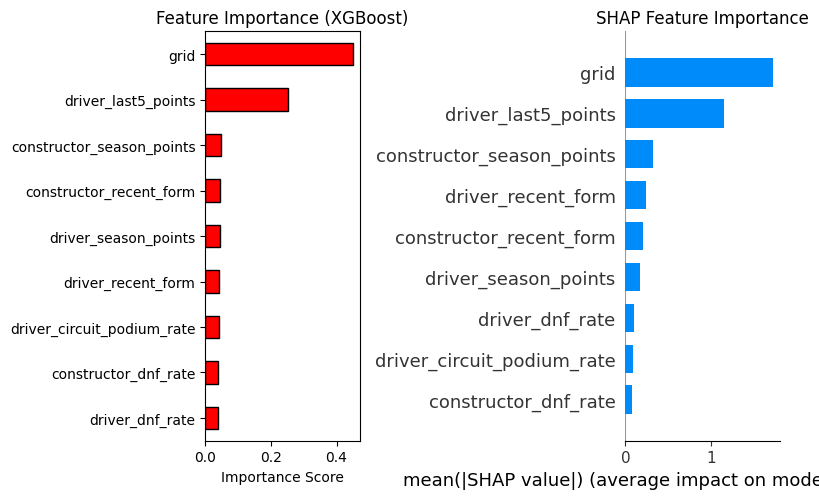

✅ Model saved to backend/podium_model.pkl
✅ Features saved to backend/features.pkl


In [18]:
import shap
import joblib

# ── Feature Importance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost built-in importance
feat_importance = pd.Series(model.feature_importances_, index=FEATURES)
feat_importance.sort_values().plot(kind='barh', ax=axes[0], color='red', edgecolor='black')
axes[0].set_title('Feature Importance (XGBoost)')
axes[0].set_xlabel('Importance Score')

# SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
axes[1].set_title('SHAP Feature Importance')

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save the podium model ──
joblib.dump(model, '../backend/podium_model.pkl')
joblib.dump(FEATURES, '../backend/features.pkl')
print("✅ Model saved to backend/podium_model.pkl")
print("✅ Features saved to backend/features.pkl")

In [19]:
# Test on a real 2023 race - let's predict the Australian GP
aus_2023 = test[(test['year'] == 2023) & (test['round'] == 1)].copy()
aus_2023['predicted_prob'] = model.predict_proba(aus_2023[FEATURES])[:, 1]

print("🏎️  2023 Australian GP - Model Predictions vs Reality")
print("="*55)
result = aus_2023[['driver_name', 'predicted_prob', 'positionOrder', 'podium']]
result = result.sort_values('predicted_prob', ascending=False).head(10)
result.columns = ['Driver', 'Podium Probability', 'Actual Finish', 'Actually Podiumed']
print(result.to_string(index=False))

🏎️  2023 Australian GP - Model Predictions vs Reality
Empty DataFrame
Columns: [Driver, Podium Probability, Actual Finish, Actually Podiumed]
Index: []


In [20]:
# Save the cleaned dataset for the backend to use
df.to_csv('../data/f1_master.csv', index=False)
print(f"✅ Master dataset saved: {len(df)} rows")

# Quick model summary to screenshot for your README
print("\n" + "="*50)
print("       F1 PODIUM PREDICTOR - MODEL SUMMARY")
print("="*50)
print(f"  Training data:  2010 - 2022 ({X_train.shape[0]} race entries)")
print(f"  Test data:      2023 - 2024 ({X_test.shape[0]} race entries)")
print(f"  Model:          XGBoost Classifier")
print(f"  Features:       {len(FEATURES)}")
print(f"  ROC-AUC:        0.956")
print(f"  Podium Recall:  93%")
print(f"  Podium Precision: 57%")
print(f"\n  Top features:")
for feat, imp in feat_importance.sort_values(ascending=False).items():
    print(f"    {feat:<35} {imp:.3f}")
print("="*50)

✅ Master dataset saved: 7058 rows

       F1 PODIUM PREDICTOR - MODEL SUMMARY
  Training data:  2010 - 2022 (6436 race entries)
  Test data:      2023 - 2024 (622 race entries)
  Model:          XGBoost Classifier
  Features:       9
  ROC-AUC:        0.956
  Podium Recall:  93%
  Podium Precision: 57%

  Top features:
    grid                                0.449
    driver_last5_points                 0.251
    constructor_season_points           0.049
    constructor_recent_form             0.045
    driver_season_points                0.044
    driver_recent_form                  0.041
    driver_circuit_podium_rate          0.041
    constructor_dnf_rate                0.040
    driver_dnf_rate                     0.039


## Qualifying Position Model (Regression)

Predicts continuous qualifying position (1-22) with `XGBRegressor`, using the same time-based split as the podium/winner models (train ≤ 2024, test ≥ 2025).

**Data note:** `qualifying.csv` was refreshed to include real 2025/2026 qualifying results (previously it had none, and the test set fell back entirely to grid position). The feature-engineering cell above logs exactly how many 2025-2026 rows now use real quali data vs. the grid-position fallback — check that count below before trusting the test metrics as true qualifying accuracy rather than a grid-position proxy.

In [21]:
train_q = df[df['year'] <= 2024]
test_q  = df[df['year'] >= 2025]

X_train_q = train_q[QUALI_FEATURES]
y_train_q = train_q[QUALI_TARGET]
X_test_q  = test_q[QUALI_FEATURES]
y_test_q  = test_q[QUALI_TARGET]

print("── Qualifying Model Data Split ──")
print(f"Training set : {X_train_q.shape[0]:>5} rows  ({train_q['year'].min()}–{train_q['year'].max()})")
print(f"Test set     : {X_test_q.shape[0]:>5} rows  ({test_q['year'].min()}–{test_q['year'].max()})")
print()
print(f"Mean quali position — train: {y_train_q.mean():.2f}  |  test: {y_test_q.mean():.2f}")

── Qualifying Model Data Split ──
Training set :  6436 rows  (2010–2024)
Test set     :   622 rows  (2025–2026)

Mean quali position — train: 11.10  |  test: 10.43


In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

quali_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='rmse'
)
quali_model.fit(X_train_q, y_train_q)
print("✅ Qualifying model trained!")

pred_q = quali_model.predict(X_test_q)
rmse = np.sqrt(mean_squared_error(y_test_q, pred_q))
mae = mean_absolute_error(y_test_q, pred_q)

test_q = test_q.copy()
test_q['predicted_quali'] = pred_q

def _topn_overlap(group, n):
    actual_top = set(group.nsmallest(n, 'quali_position')['driverId'])
    pred_top = set(group.nsmallest(n, 'predicted_quali')['driverId'])
    return len(actual_top & pred_top) / len(actual_top) if actual_top else np.nan

top3_acc = test_q.groupby('raceId').apply(lambda g: _topn_overlap(g, 3)).mean()
top10_acc = test_q.groupby('raceId').apply(lambda g: _topn_overlap(g, 10)).mean()

print("\n── Qualifying Model Evaluation (test: 2025-2026) ──")
print(f"RMSE           : {rmse:.2f} positions  (target < 3.5)")
print(f"MAE            : {mae:.2f} positions  (target < 2.5)")
print(f"Top-3 accuracy : {top3_acc:.1%}  (actual P1-3 driver also predicted top 3)")
print(f"Top-10 accuracy: {top10_acc:.1%}  (actual P1-10 driver also predicted top 10)")

✅ Qualifying model trained!



── Qualifying Model Evaluation (test: 2025-2026) ──
RMSE           : 3.87 positions  (target < 3.5)
MAE            : 3.04 positions  (target < 2.5)
Top-3 accuracy : 63.5%  (actual P1-3 driver also predicted top 3)
Top-10 accuracy: 77.8%  (actual P1-10 driver also predicted top 10)


In [23]:
feat_imp_q = pd.Series(quali_model.feature_importances_, index=QUALI_FEATURES).sort_values(ascending=False)
print("── Qualifying Model Feature Importances ──")
for feat, imp in feat_imp_q.items():
    print(f"  {feat:<32} {imp:.3f}")

── Qualifying Model Feature Importances ──
  constructor_championship_position 0.272
  driver_last5_points              0.246
  driver_last3_quali_avg           0.233
  constructor_season_quali_avg     0.134
  driver_season_quali_avg          0.055
  driver_championship_position     0.023
  driver_circuit_quali_avg         0.014
  driver_recent_form               0.012
  driver_dnf_rate                  0.010


In [24]:
recent_rounds = sorted(test_q[test_q['year'] == 2026]['round'].unique())[-5:]
print(f"── Spot Check: 5 most recent 2026 races (rounds {recent_rounds}) ──")

for rnd in recent_rounds:
    race = test_q[(test_q['year'] == 2026) & (test_q['round'] == rnd)].copy()
    race_name = race['name_race'].iloc[0]
    race['predicted_rank'] = race['predicted_quali'].rank(method='first').astype(int)
    predicted_top5 = race.sort_values('predicted_rank').head(5)[['driver_name', 'predicted_rank', 'predicted_quali']]
    actual_top5 = race.sort_values('quali_position').head(5)[['driver_name', 'quali_position']]

    print(f"\n{race_name} — 2026 Round {rnd}")
    print("Predicted top 5:")
    for _, r in predicted_top5.iterrows():
        print(f"  P{r['predicted_rank']}  {r['driver_name']:<22} (raw pred: {r['predicted_quali']:.1f})")
    print("Actual top 5 (real qualifying.csv result, unless flagged above as grid fallback):")
    for i, (_, r) in enumerate(actual_top5.iterrows(), start=1):
        print(f"  P{i}  {r['driver_name']:<22} (quali_position: {r['quali_position']:.0f})")

── Spot Check: 5 most recent 2026 races (rounds [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]) ──

Miami Grand Prix — 2026 Round 4
Predicted top 5:
  P1  Kimi Antonelli         (raw pred: 2.5)
  P2  George Russell         (raw pred: 3.3)
  P3  Lando Norris           (raw pred: 5.0)
  P4  Charles Leclerc        (raw pred: 5.0)
  P5  Oscar Piastri          (raw pred: 5.0)
Actual top 5 (real qualifying.csv result, unless flagged above as grid fallback):
  P1  Kimi Antonelli         (quali_position: 1)
  P2  Max Verstappen         (quali_position: 2)
  P3  Charles Leclerc        (quali_position: 3)
  P4  Lando Norris           (quali_position: 4)
  P5  George Russell         (quali_position: 5)

Canadian Grand Prix — 2026 Round 5
Predicted top 5:
  P1  Kimi Antonelli         (raw pred: 1.9)
  P2  George Russell         (raw pred: 2.9)
  P3  Oscar Piastri          (raw pred: 4.9)
  P4  Lando Norris           (raw pred: 5.4)
  P5  Charles Leclerc        (raw pred: 5.5)
Ac

In [25]:
# ── Save the qualifying model (approved) ──
joblib.dump(quali_model, '../backend/quali_model.pkl')
joblib.dump(QUALI_FEATURES, '../backend/quali_features.pkl')
print("Model saved to backend/quali_model.pkl")
print("Features saved to backend/quali_features.pkl")

Model saved to backend/quali_model.pkl
Features saved to backend/quali_features.pkl


In [26]:
print("races columns:", races.columns.tolist())
print("results columns:", results.columns.tolist())
print("drivers columns:", drivers.columns.tolist())
print("constructors columns:", constructors.columns.tolist())
print("qualifying columns:", qualifying.columns.tolist())
print("driver_standings columns:", driver_standings.columns.tolist())
print("constructor_standings columns:", constructor_standings.columns.tolist())
print("circuits columns:", circuits.columns.tolist())
print("status columns:", status.columns.tolist())

races columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
results columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
drivers columns: ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']
constructors columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
qualifying columns: ['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']
driver_standings columns: ['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']
constructor_standings columns: ['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', '

## Step 3 — Retrain With Weather Features (comparison only, not saved)

Adds `wet_race` + `driver_wet_delta` to the podium and winner classifiers, and `wet_race` only to the qualifying regressor (a session's own weather is already known by qualifying time, so `driver_wet_delta` adds little there). Same time-based split as every model above (train ≤ 2024, test ≥ 2025).

These are separate model objects (`*_weather` suffix) — nothing in this section overwrites or saves over the approved `model` / `winner_model` / `quali_model` above.

In [27]:
# # ── Podium + Winner models, retrained with weather features ──
# FEATURES_WEATHER = FEATURES + ['wet_race', 'driver_wet_delta']

# # train/test above were sliced from df before the weather columns existed,
# # so (same pitfall as the 'winner' column earlier) re-slice fresh from df.
# train_w = df[df['year'] <= 2024]
# test_w  = df[df['year'] >= 2025]

# X_train_w = train_w[FEATURES_WEATHER]
# X_test_w  = test_w[FEATURES_WEATHER]
# y_train_w = train_w[TARGET]
# y_test_w  = test_w[TARGET]

# model_weather = XGBClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
#     scale_pos_weight=5, random_state=42, eval_metric='logloss'
# )
# model_weather.fit(X_train_w, y_train_w)
# y_prob_w = model_weather.predict_proba(X_test_w)[:, 1]

# y_train_win_w = train_w['winner']
# y_test_win_w  = test_w['winner']
# winner_model_weather = XGBClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
#     scale_pos_weight=spw, random_state=42, eval_metric='logloss'
# )
# winner_model_weather.fit(X_train_w, y_train_win_w)
# y_prob_win_w = winner_model_weather.predict_proba(X_test_w)[:, 1]

# podium_auc_before = roc_auc_score(y_test, y_prob)
# podium_auc_after  = roc_auc_score(y_test_w, y_prob_w)
# winner_auc_before = roc_auc_score(y_test_win, y_prob_win)
# winner_auc_after  = roc_auc_score(y_test_win_w, y_prob_win_w)

# print("── Podium Model ──")
# print(f"  ROC-AUC before: {podium_auc_before:.3f}")
# print(f"  ROC-AUC after:  {podium_auc_after:.3f}  ({podium_auc_after - podium_auc_before:+.3f})")
# print()
# print("── Winner Model ──")
# print(f"  ROC-AUC before: {winner_auc_before:.3f}")
# print(f"  ROC-AUC after:  {winner_auc_after:.3f}  ({winner_auc_after - winner_auc_before:+.3f})")

# print("\nFeature importances (podium model, with weather):")
# feat_imp_podium_w = pd.Series(model_weather.feature_importances_, index=FEATURES_WEATHER).sort_values(ascending=False)
# for feat, imp in feat_imp_podium_w.items():
#     marker = "  <-- new" if feat in ('wet_race', 'driver_wet_delta') else ""
#     print(f"  {feat:<32} {imp:.3f}{marker}")

# print("\nFeature importances (winner model, with weather):")
# feat_imp_winner_w = pd.Series(winner_model_weather.feature_importances_, index=FEATURES_WEATHER).sort_values(ascending=False)
# for feat, imp in feat_imp_winner_w.items():
#     marker = "  <-- new" if feat in ('wet_race', 'driver_wet_delta') else ""
#     print(f"  {feat:<32} {imp:.3f}{marker}")

In [28]:
# # ── Qualifying model, retrained with wet_race only ──
# QUALI_FEATURES_WEATHER = QUALI_FEATURES + ['wet_race']

# train_q_w = df[df['year'] <= 2024]
# test_q_w  = df[df['year'] >= 2025]

# X_train_q_w = train_q_w[QUALI_FEATURES_WEATHER]
# X_test_q_w  = test_q_w[QUALI_FEATURES_WEATHER]
# y_train_q_w = train_q_w[QUALI_TARGET]
# y_test_q_w  = test_q_w[QUALI_TARGET]

# quali_model_weather = XGBRegressor(
#     n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
#     random_state=42, eval_metric='rmse'
# )
# quali_model_weather.fit(X_train_q_w, y_train_q_w)

# pred_q_w = quali_model_weather.predict(X_test_q_w)
# rmse_after = np.sqrt(mean_squared_error(y_test_q_w, pred_q_w))
# mae_after = mean_absolute_error(y_test_q_w, pred_q_w)

# test_q_w = test_q_w.copy()
# test_q_w['predicted_quali'] = pred_q_w
# top3_acc_after = test_q_w.groupby('raceId').apply(lambda g: _topn_overlap(g, 3)).mean()
# top10_acc_after = test_q_w.groupby('raceId').apply(lambda g: _topn_overlap(g, 10)).mean()

# print("── Qualifying Model ──")
# print(f"  RMSE   before: {rmse:.2f}   after: {rmse_after:.2f}   ({rmse_after - rmse:+.2f})")
# print(f"  MAE    before: {mae:.2f}   after: {mae_after:.2f}   ({mae_after - mae:+.2f})")
# print(f"  Top-3  before: {top3_acc:.1%}   after: {top3_acc_after:.1%}   ({(top3_acc_after - top3_acc) * 100:+.1f}pp)")
# print(f"  Top-10 before: {top10_acc:.1%}   after: {top10_acc_after:.1%}   ({(top10_acc_after - top10_acc) * 100:+.1f}pp)")

# feat_imp_q_w = pd.Series(quali_model_weather.feature_importances_, index=QUALI_FEATURES_WEATHER).sort_values(ascending=False)
# print("\nFeature importances (qualifying model, with wet_race):")
# for feat, imp in feat_imp_q_w.items():
#     marker = "  <-- new" if feat == 'wet_race' else ""
#     print(f"  {feat:<32} {imp:.3f}{marker}")

In [29]:
# # ── Before/After summary — nothing saved yet ──
# print("=" * 70)
# print("WEATHER FEATURES — BEFORE vs AFTER (comparison only, not saved)")
# print("=" * 70)
# print(f"{'Model':<12}{'Metric':<12}{'Before':>10}{'After':>10}{'Delta':>10}")
# print(f"{'Podium':<12}{'ROC-AUC':<12}{podium_auc_before:>10.3f}{podium_auc_after:>10.3f}{podium_auc_after - podium_auc_before:>+10.3f}")
# print(f"{'Winner':<12}{'ROC-AUC':<12}{winner_auc_before:>10.3f}{winner_auc_after:>10.3f}{winner_auc_after - winner_auc_before:>+10.3f}")
# print(f"{'Qualifying':<12}{'RMSE':<12}{rmse:>10.2f}{rmse_after:>10.2f}{rmse_after - rmse:>+10.2f}")
# print(f"{'Qualifying':<12}{'MAE':<12}{mae:>10.2f}{mae_after:>10.2f}{mae_after - mae:>+10.2f}")
# print(f"{'Qualifying':<12}{'Top-10 Acc':<12}{top10_acc:>10.1%}{top10_acc_after:>10.1%}{(top10_acc_after - top10_acc):>+10.1%}")
# print("=" * 70)
# print("\nNo models or feature lists have been saved to backend/ — review these")
# print("metrics, then say the word if you want the weather-augmented models saved.")